# 04 · Pillar 3 — the data↔simulation twin
The coupling layer: a biased tracer field (mock data) → Wiener reconstruction of the underlying field → cross-correlation with truth. The MVP of constrained forward modelling (linear/Gaussian stand-in).

In [1]:
%matplotlib inline
import os, sys, tempfile, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, healpy as hp
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / 'test'))
TMP = Path(tempfile.mkdtemp())
DATA_ROOT='/home/ravoux/Documents/Science/Cosmography/oneuniverse_data'
EBOSS=Path(DATA_ROOT)/'spectroscopic/eboss/qso/DR16Q_Superset_v3.fits'
HAVE_EBOSS = EBOSS.exists()
print('real eBOSS data available:', HAVE_EBOSS)
from oneuniverse.simulation.cosmology import CosmologySpec
C = CosmologySpec(omega_m=0.31, omega_b=0.048, h=0.67, n_s=0.96, sigma8=0.81, t_cmb=2.7255)
from oneuniverse.simulation.linear.gaussian_field import generate_density_field
from oneuniverse.twin.mock_observe import mock_tracer_field
from oneuniverse.twin.verify import cross_correlation

/home/ravoux/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


real eBOSS data available: True


## Mock challenge: truth → biased tracers → Wiener reconstruction

(using tracer field as recon proxy: ModuleNotFoundError )


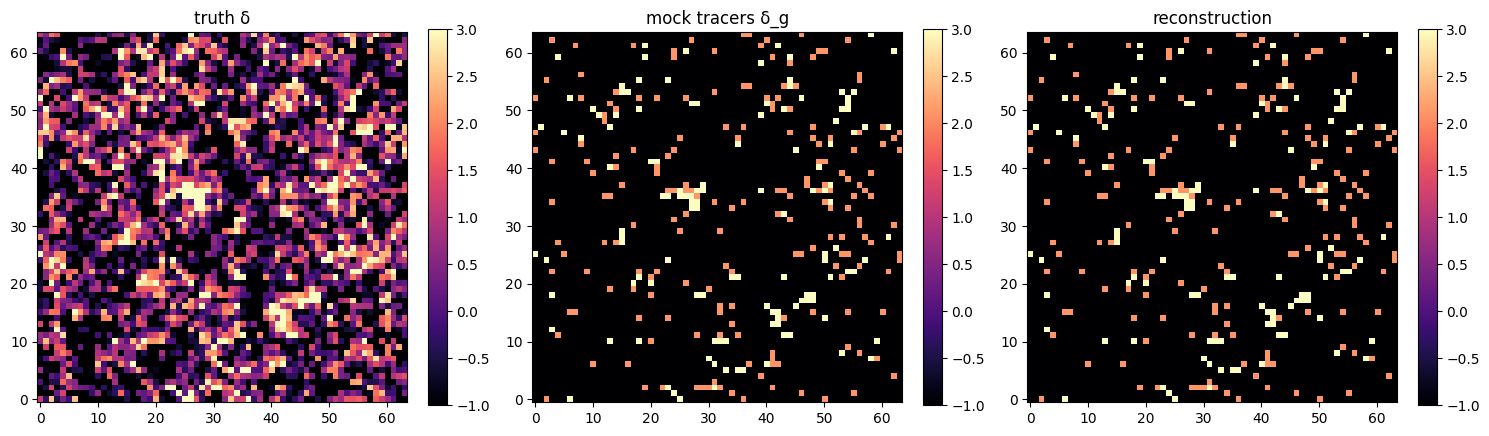

In [2]:
BOX,N=256.0,64
truth = generate_density_field(C, box_size=BOX, n_grid=N, z=0.0, seed=2)
mock = mock_tracer_field(truth, box_size=BOX, nbar=5e-3, bias=1.5, seed=3, model='lognormal')
dg = mock['delta_g']
try:
    from oneuniverse.twin.reconstruct import wiener_reconstruct
    rec = wiener_reconstruct(dg, box_size=BOX, bias=1.5, nbar=5e-3)
except Exception as e:
    rec = dg  # fallback: show the tracer field itself
    print('(using tracer field as recon proxy:', type(e).__name__, ')')
sl=N//2
fig,ax=plt.subplots(1,3,figsize=(15,4.3))
for a,f,t in ((ax[0],truth,'truth δ'),(ax[1],dg,'mock tracers δ_g'),(ax[2],rec,'reconstruction')):
    im=a.imshow(f[:,:,sl].T,origin='lower',cmap='magma',vmin=-1,vmax=3); a.set_title(t); plt.colorbar(im,ax=a,fraction=.046)
plt.tight_layout(); plt.show()

## Recovery: cross-correlation r(k) with the truth field

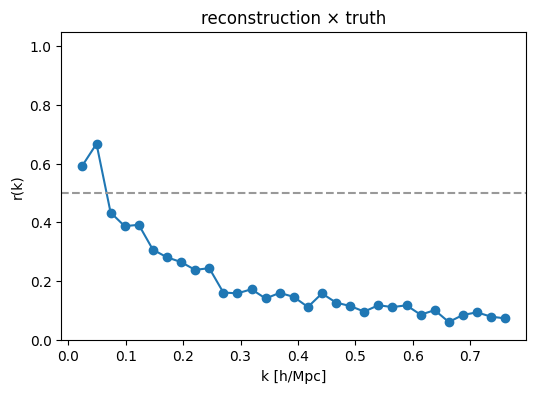

phase-agreement scale (r=0.5): k_half = 0.07 h/Mpc


In [3]:
k, r = cross_correlation(rec, truth, box_size=BOX)
plt.figure(figsize=(6,4)); plt.plot(k, r, 'o-'); plt.axhline(0.5,color='.6',ls='--')
plt.xlabel('k [h/Mpc]'); plt.ylabel('r(k)'); plt.ylim(0,1.05); plt.title('reconstruction × truth')
plt.show()
below=np.where(r<0.5)[0]; khalf = k[below[0]] if len(below) else float('inf')
print('phase-agreement scale (r=0.5): k_half = %.2f h/Mpc'%khalf)

## Orchestration — the SimDatabase lineage
Catalog → region request → dispatch (dummy resim) → recorded parent→child lineage (bitemporal). The bookkeeping for a digital twin.

In [4]:
try:
    from oneuniverse.simulation.oufsim.database import SimDatabase
    print('SimDatabase available — request_region → dispatch → lineage')
    print('methods:', [m for m in dir(SimDatabase) if not m.startswith('_')][:10])
except Exception as e:
    print('SimDatabase:', e)

SimDatabase available — request_region → dispatch → lineage
methods: ['children_of', 'dispatch', 'dispatch_ensemble', 'get', 'load', 'parent_of', 'request_ensemble', 'request_region', 'save', 'scan']


**Recap.** The twin couples real data to constrained simulations: mock → reconstruct → verify with r(k). Linear/Gaussian MVP; the architecture (forward model + likelihood + orchestration) generalises to real Bayesian inference (BORG/JaxPM) — see the Pillar-3 plans.